In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from DFTStructureGenerator.draw import plot_scatter_fit, plot_distribution, plot_panel
from DFTStructureGenerator.Build_DataBase import build_databases
from DFTStructureGenerator.Tool import get_bond_angle
from tqdm import tqdm
from rdkit import Chem
from DFTStructureGenerator.logfile_process import Logfile
from DFTStructureGenerator import B_N_Cl
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from ase import Atoms
from ase.db import connect

In [ ]:
duplicate_N_id = [9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376]



Borane_df = pd.read_csv(r'Data\csvs\reactants_B.csv')
nu_df = pd.read_csv(r'Data\csvs\reactants_N.csv').dropna(subset=['G_energy_r'])
Cl_df = pd.read_csv(r'Data\csvs\reactants_Cl.csv')
Borane_nu_df = pd.read_csv(r'Data\csvs\reactants_B_N.csv')
reaction_df = pd.read_csv(r'Data\TS\Borane_all.csv')


# raise NameError
combined_data = {}
temp_combined_data = {}

# ======================== B monomer (open shell) ========================
for row_id, row in Borane_df.iterrows():
    idx, conf_idxs_r, G = row['Index'], int(row['conf_idxs_r']), row['G_energy_r']
    mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\B_{idx:05}_r.mol', removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
    smiles = Chem.MolToSmiles(mol)
    log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_single\B_{idx:05}_r_{conf_idxs_r:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    # Descriptor: SPE log
    spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
    spe_log = Logfile(spe_log_file)
    dipole_moment = spe_log.get_dipole()
    _, spin_densities = spe_log.read_charge_spin_density()
    orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]  # Open the shell and take the first 2
    combined_data[f'B_{idx:05}'] = {
        "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
        "dipole_moment": dipole_moment,
        "spin_densities": spin_densities,
        "homo_energy_kcal": orbital_energies[0],
        "lumo_energy_kcal": orbital_energies[1],
    }

# ======================== LB / Nu monomer (closed shell) ========================
for row_id, row in nu_df.iterrows():
    idx, conf_idxs_r, G = row['Index'], int(row['conf_idxs_r']), row['G_energy_r']
    mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\N_{idx:05}_r.mol', removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
    smiles = Chem.MolToSmiles(mol)
    log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\N_single\N_{idx:05}_r_{conf_idxs_r:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    # Descriptor: SPE log
    spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
    spe_log = Logfile(spe_log_file)
    dipole_moment = spe_log.get_dipole()
    orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])  # Closed shell layer returns 2
    combined_data[f'LB_{idx:05}'] = {
        "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
        "dipole_moment": dipole_moment,
        "homo_energy_kcal": orbital_energies[0],
        "lumo_energy_kcal": orbital_energies[1],
    }

# ======================== Cl substrate (r closed shell) / C radical (p open shell) ========================
for row_id, row in Cl_df.iterrows():
    idx, conf_idxs_r, conf_idxs_p, G_r, G_p = row['Index'], int(row['conf_idxs_r']), int(row['conf_idxs_p']), row['G_energy_r'], row['G_energy_p']
    for conf_id, state, G in [[conf_idxs_r, 'r', G_r], [conf_idxs_p, 'p', G_p]]:
        mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\Cl_{idx:05}_{state}.mol', removeHs=False)
        [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
        smiles = Chem.MolToSmiles(mol)
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\Cl_{state}\Cl_{idx:05}_{state}_{conf_id:04}.log'
        log = Logfile(log_file)
        atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
        # Descriptor: SPE log
        spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
        spe_log = Logfile(spe_log_file)
        chg_file = spe_log_file.replace(".log", ".chg").replace("GS_SPE", "GS_SPE_wfn")
        hirshfeld_charges = B_N_Cl.FormatConverter.read_chg_file(chg_file)['charge'].to_list()
        dipole_moment = spe_log.get_dipole()
        entry = {
            "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
            "hirshfeld_charges": hirshfeld_charges,
            "dipole_moment": dipole_moment,
        }
        if state == 'p':
            # c_radical: open shell → spin density + orbital [:2]
            _, spin_densities = spe_log.read_charge_spin_density()
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]
            entry["spin_densities"] = spin_densities
        else:
            # Cl_r: closed shell
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])
        entry["homo_energy_kcal"] = orbital_energies[0]
        entry["lumo_energy_kcal"] = orbital_energies[1]
        combined_data[f'Cl_{idx:05}_{state}'] = entry

# ======================== TS transition state ========================
BN_smiles = {}

for row_id, row in tqdm(reaction_df.iterrows()):
    B_idx, N_idx, Cl_idx, conf_id, G, N_atom, AAM = row['B_Index'], row['N_Index'], row['Cl_Index'], row['conf_idxs_ts'], row['TS_G'], int(row['N_Atomid']), row['AAM']
    log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}.log'
    if not os.path.exists(log_file):
        log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}_{conf_id:04}.log'
    
    irc_forward = log_file.replace("TS_needIRC", "IRC_Full").replace(".log", "forward.log")
    irc_reverse = log_file.replace("TS_needIRC", "IRC_Full").replace(".log", "reverse.log")
    log = Logfile(log_file,ignore_print=True)
    first_unreal_freq = log.first_unreal_freq
    first_unreal_freq_matrix = np.array(log.unreal_freq_matrix)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])

    # IRC endpoint structure
    irc_fwd_positions = None
    irc_rev_positions = None
    if os.path.exists(irc_forward):
        irc_fwd_log = Logfile(irc_forward, ignore_print=True)
        irc_fwd_positions = irc_fwd_log.running_positions[-1].tolist()
    if os.path.exists(irc_reverse):
        irc_rev_log = Logfile(irc_reverse,ignore_print=True)
        irc_rev_positions = irc_rev_log.running_positions[-1].tolist()

    temp_combined_data[f'B_{B_idx:05}_LB_{N_idx:05}_Cl_{Cl_idx:05}'] = {
        "smiles": AAM, "atoms": atoms, "gibbs_hartree": G,
        "imaginary_frequency_cm_1": float(first_unreal_freq),
        "imaginary_freq_displacement": first_unreal_freq_matrix.tolist(),
        "irc_forward_positions": irc_fwd_positions,
        "irc_reverse_positions": irc_rev_positions,
    }
    BN_name = f'{B_idx:05}_{N_idx:05}'
    if N_idx in duplicate_N_id:
        BN_name = f'{B_idx:05}_{N_idx:05}_{N_atom}'

    BN_smiles[f'{BN_name}_r'] = row['AAM'].split(">>")[0].split('.')[0]
    BN_smiles[f'{BN_name}_p'] = row['AAM'].split(">>")[1].split('.')[0]


# ======================== B-LB complex (r open shell / p closed shell) ========================
for row_id, row in tqdm(Borane_nu_df.iterrows()):
    B_idx, N_idx, conf_idxs_r, conf_idxs_p, G_r, G_p, N_atom, B_atom = row['B_Index'], row['N_Index'], int(row['conf_idxs_r']), int(row['conf_idxs_p']), row['G_energy_r'], row['G_energy_p'], int(row['N_Atomid']), int(row['B_Atomid'])
    B_smiles = row['B_smiles'] 
    N_smiles = row['N_smiles']
    react_mol, product_mol = B_N_Cl.generate_ts_mol(B_smiles, N_smiles, B_atom, N_atom)
    react_smiles, product_smiles = Chem.MolToSmiles(react_mol), Chem.MolToSmiles(product_mol)
    for conf_id, state, G, smiles in [[conf_idxs_r, 'r', G_r, react_smiles], [conf_idxs_p, 'p', G_p, product_smiles]]:
        BN_name = f'{B_idx:05}_{N_idx:05}'
        if N_idx in duplicate_N_id:
            BN_name = f'{B_idx:05}_{N_idx:05}_{N_atom}'
        # if f'{BN_name}_{state}' not in BN_smiles.keys():
        #     continue
        # smiles = BN_smiles[f'{BN_name}_{state}']
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_{state}\B_{B_idx:05}_Nu_{N_idx:05}_{state}_{conf_id:04}.log'
        if N_idx in duplicate_N_id:
            log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_{state}_d\B_{B_idx:05}_Nu_{N_idx:05}_Naid_{N_atom:05}_{state}_{conf_id:04}.log'
        if not os.path.exists(log_file):
            print(BN_name, 'Not Found')
        log = Logfile(log_file,ignore_print=True)
        atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
        # Descriptor: SPE log
        spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
        spe_log = Logfile(spe_log_file,ignore_print=True)
        chg_file = spe_log_file.replace(".log", ".chg").replace("GS_SPE", "GS_SPE_wfn")
        hirshfeld_charges = B_N_Cl.FormatConverter.read_chg_file(chg_file)['charge'].to_list()
        dipole_moment = spe_log.get_dipole()
        entry = {
            "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
            "hirshfeld_charges": hirshfeld_charges,
            "dipole_moment": dipole_moment,
        }
        if state == 'r':
            # complex_r: open shell → spin density + orbital take[:2]
            _, spin_densities = spe_log.read_charge_spin_density()
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]
            entry["spin_densities"] = spin_densities
        else:
            # complex_p: closed shell
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])
        entry["homo_energy_kcal"] = orbital_energies[0]
        entry["lumo_energy_kcal"] = orbital_energies[1]
        combined_data[f'B_{B_idx:05}_LB_{N_idx:05}_{state}'] = entry

combined_data = combined_data | temp_combined_data

In [ ]:
build_databases(combined_data, rewrite=True)

In [4]:
db = connect("boron_ccl.db")
reaction_df = pd.read_csv(r"Data\TS\Borane_all.csv")

In [ ]:
db.select(category=cat)

In [7]:
categories = ["B", "LB", "Cl", "complex_r", "complex_p", "ts", "c_radical"]

counts = pd.Series(
    {cat: db.count(category=cat) for cat in categories},
    name="count"
)

print("Total:", db.count())
print(counts)


Total: 50057
B               55
LB             387
Cl             179
complex_r    20010
complex_p    20010
ts            9237
c_radical      179
Name: count, dtype: int64


# Figure 1

[0, 24, 30, 1]
B_Radical_TypeColors


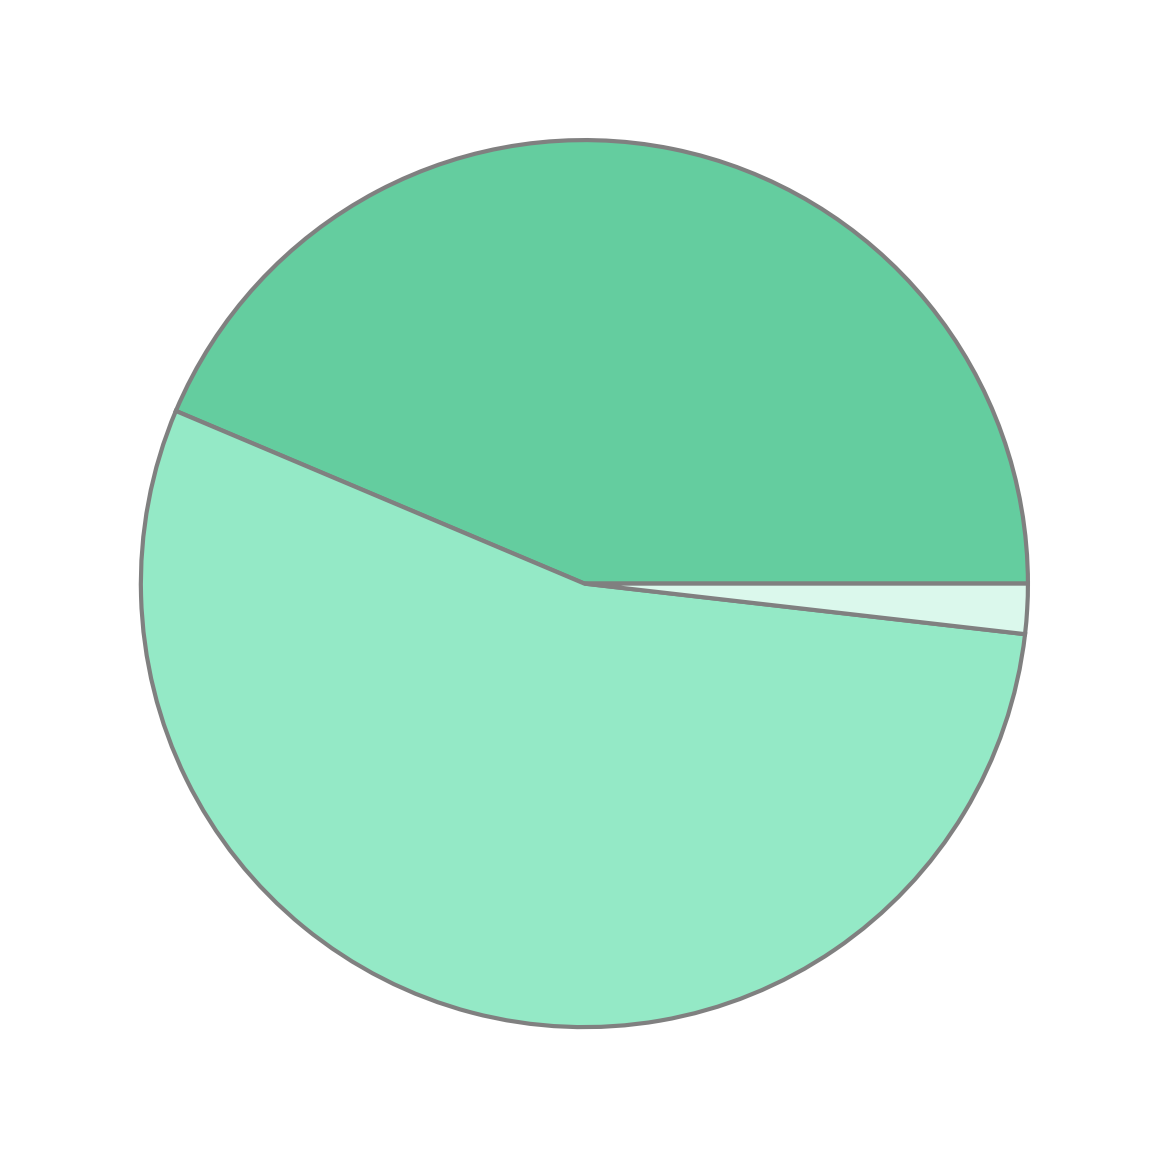

In [333]:
# Make a pie chart of all types of B
all_B_type = [0,0,0,0]
for row in db.select(category="B"):
    B_atom = [atom for atom in Chem.MolFromSmiles(row.smiles).GetAtoms() if atom.GetSymbol() == "B"][0]
    H_neighbors = B_atom.GetTotalNumHs()
    all_B_type[H_neighbors] += 1
print(all_B_type)
colors = ['#ff9999', "#64cd9f", "#94e9c6", "#dbf8ec"]
plt.figure(dpi=300)
plt.pie(all_B_type, 
        colors=colors, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_B_Radical_TypeColors.png", dpi=300)

[222, 75, 89, 0] 386
B_Radical_TypeColors


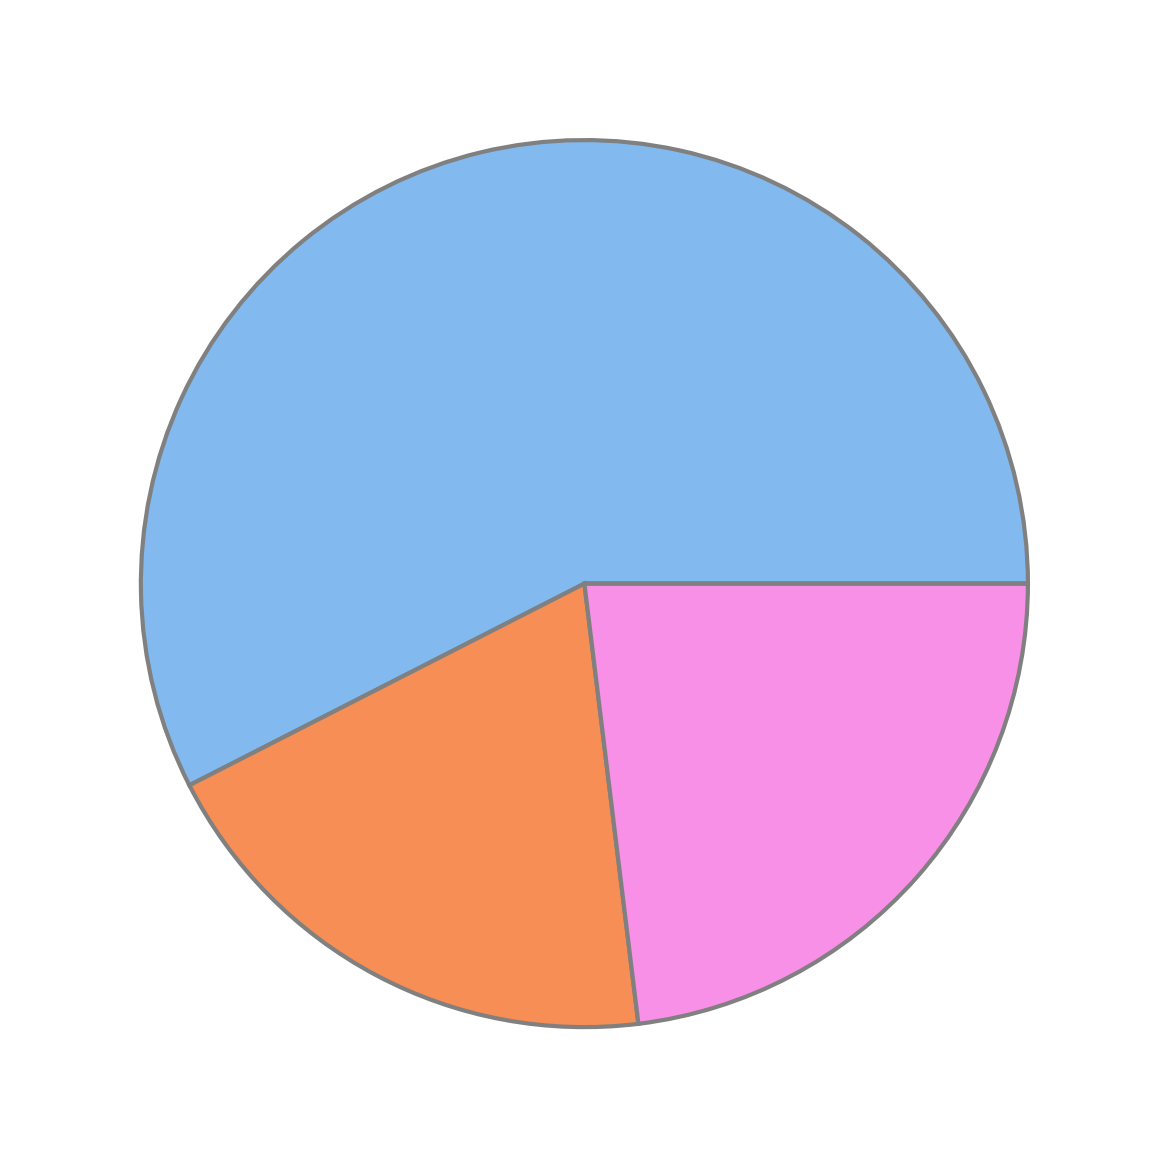

In [ ]:
# Make a pie chart of all types of LB
Anime_LB = np.arange(0,69)
Phosphine_LB = np.arange(69, 144)
NHC_LB = np.arange(144, 234)
Ar_LB = np.arange(234, 388)
all_nu_types = [0] * 4
for row in db.select(category="LB"):
    for id, nu in enumerate([np.append(Anime_LB, Ar_LB), Phosphine_LB, NHC_LB, ]):
        if int(row.key.split("_")[1]) in nu:
            all_nu_types[id] += 1
print(all_nu_types, np.sum(all_nu_types))
colors = [ "#82baef", "#f68e56", "#f990e7"]
plt.figure(dpi=300)
plt.pie(all_nu_types, colors=colors, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_TypeColors.png", dpi=300)

In [318]:
num_Cl_substit

[102, 40, 36, 1]

[1, 36, 40, 102, 0, 0] [1, 36, 40, 102, 0, 0] 179


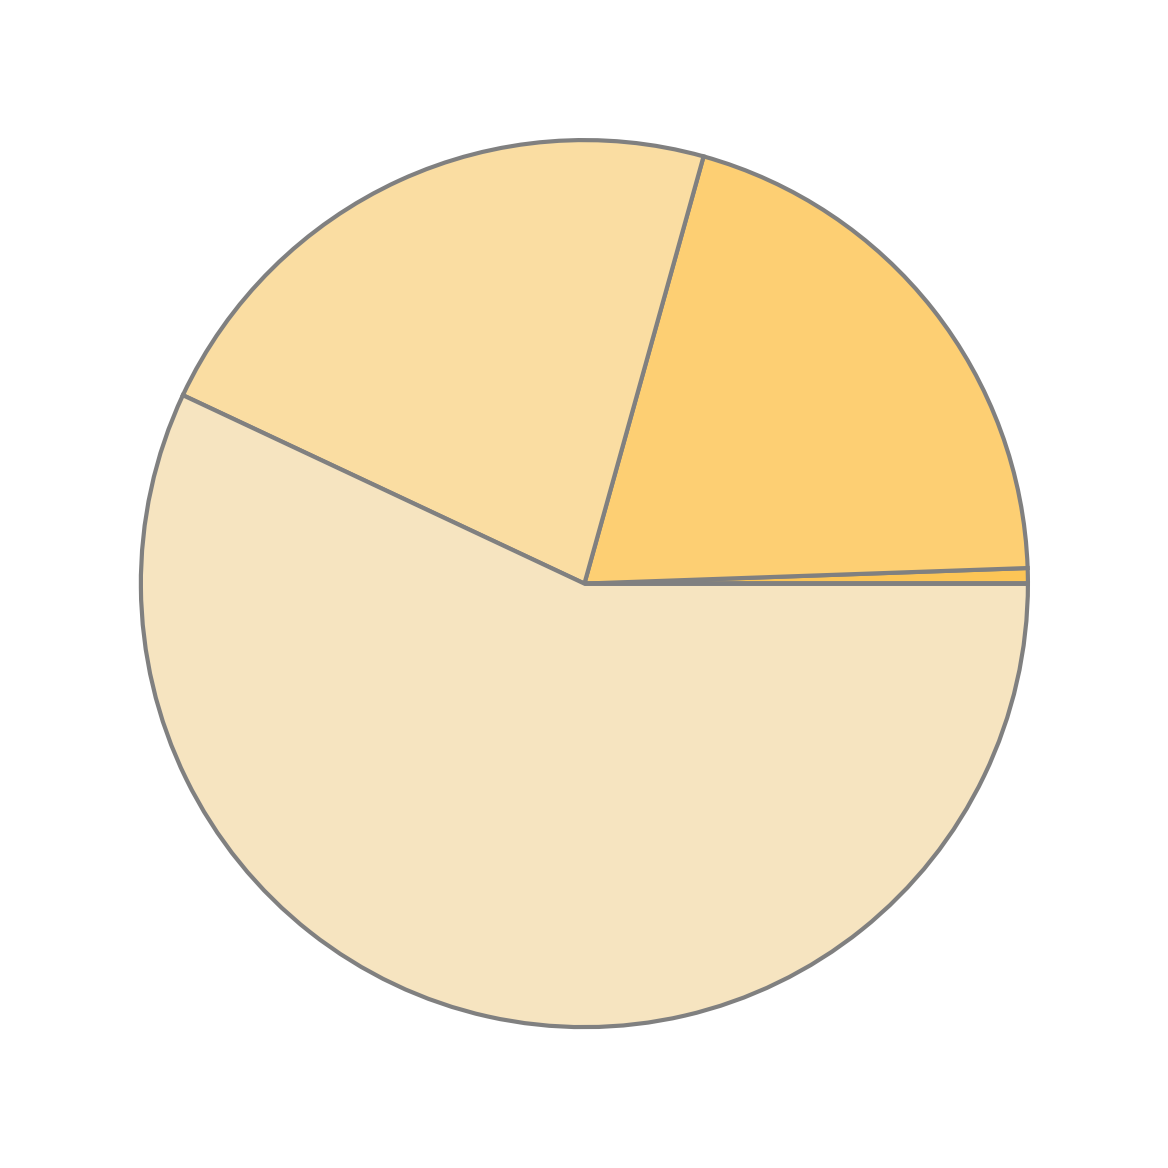

In [352]:
# Make a pie chart of all types of Cl
num_Cl_substit = [0,0,0,0,0,0]
for row in db.select(category="Cl"):
    Cl_mol = Chem.AddHs(Chem.MolFromSmiles(row.smiles))
    if Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*(Cl)(Cl)Cl")):
        num_Cl_substit[0] += 1
    elif Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*(Cl)Cl")):
        num_Cl_substit[1] += 1
    elif Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*Cl")):
        num_Cl_substit[2] += 1
    else:
        num_Cl_substit[3] += 1
colors = ["#fcc556", "#fdcf73", "#fadda2", "#f6e4c0", "#f6efe0"]
print(num_Cl_substit, num_Cl_substit, np.sum(num_Cl_substit))
plt.figure(dpi=300)
# plt.pie(num_Cl_substit, colors=colors, 
#         wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
# plt.savefig("Figure/Figure1_Cl_ClAtomColors.png", dpi=300)
# plt.show()
plt.pie(num_Cl_substit, colors=colors, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
plt.savefig("Figure/Figure1_Cl_Csp23Colors.png", dpi=300)
plt.show()


## LB details

[68, 112, 40, 2]
B_Radical_TypeColors


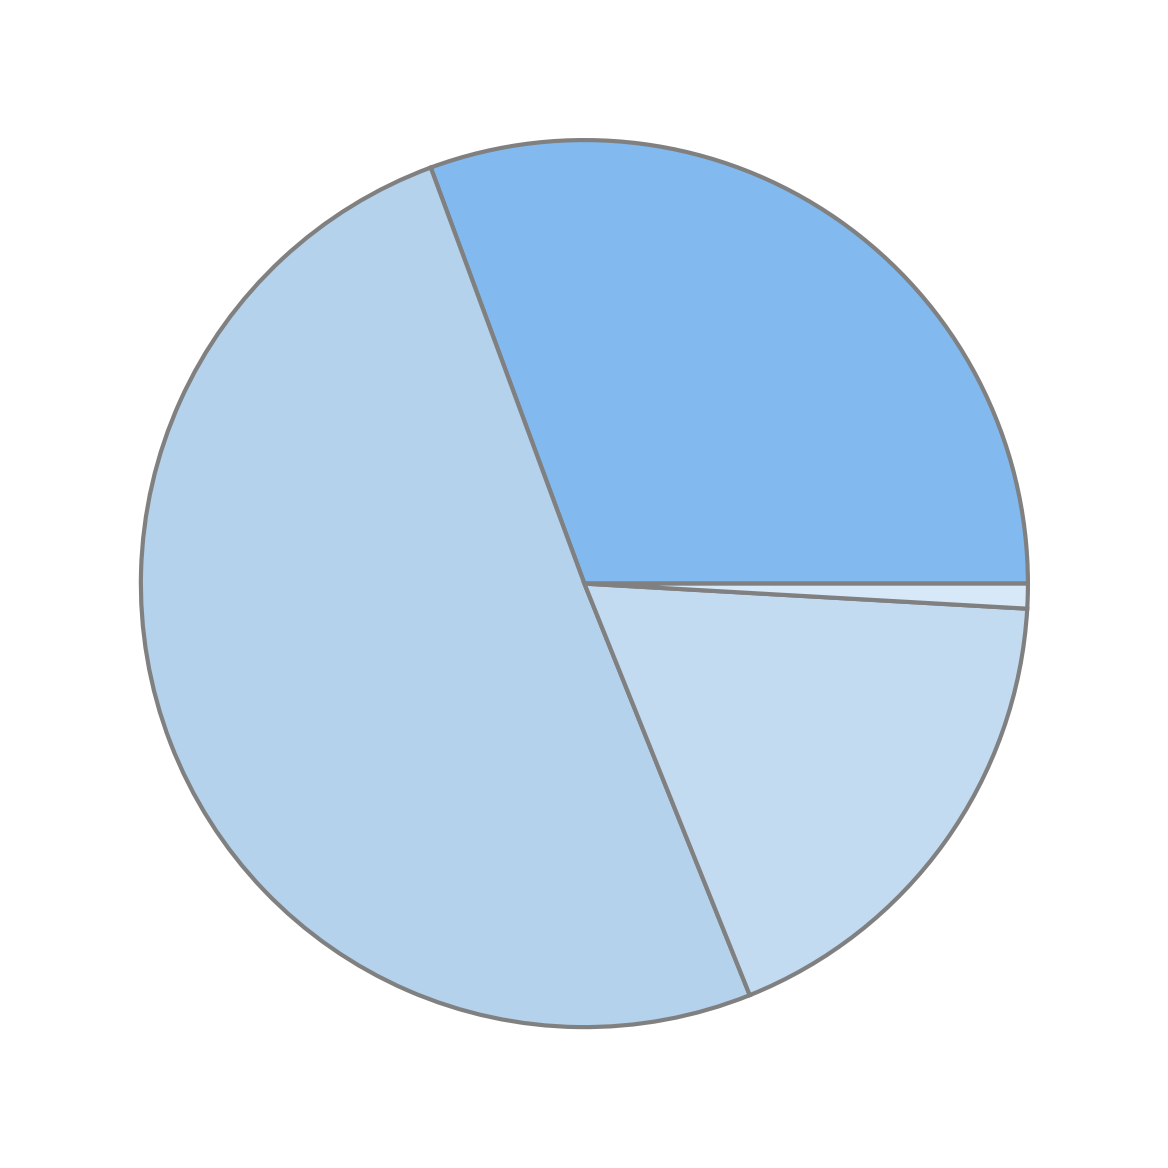

In [ ]:
# Making a pie chart of Phosphine's LB
all_lb_type = [[], [], [], []]
colors = ["#82baef", "#b4d2ec", "#c2dbf1", "#d7e8f8"]
for row in db.select(category="LB"):
    if int(row.key.split("_")[1]) in np.append(Anime_LB, Ar_LB):
        if Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("n1*****1")):
            all_lb_type[1].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("n1****1")):
            all_lb_type[2].append(row.smiles)
        elif int(row.key.split("_")[1]) in Anime_LB:
            all_lb_type[0].append(row.smiles)
        else:
            all_lb_type[3].append(row.smiles)
print([len(each) for each in all_lb_type])
plt.figure(dpi=300)
plt.pie([len(each) for each in all_lb_type], colors=colors, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_TypeColors.png", dpi=300)

[33, 42, 0, 0]
B_Radical_TypeColors


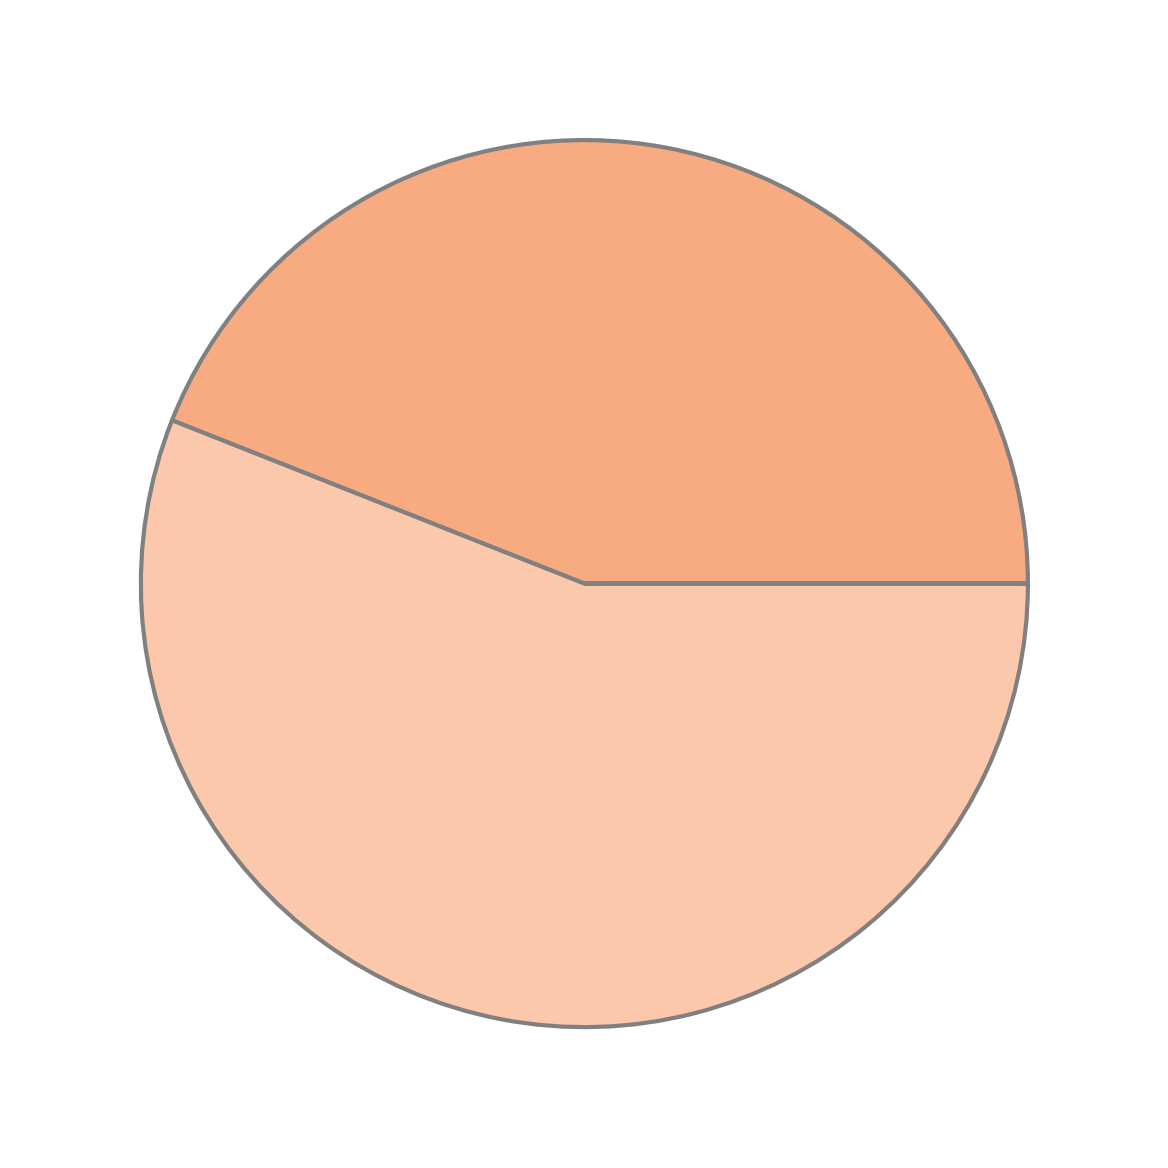

In [ ]:
# Making a pie chart of Phosphine's LB
all_P_type = [[], [], [], []]
for row in db.select(category="LB"):
    if int(row.key.split("_")[1]) in Phosphine_LB:
        if Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[P,p]a")):
            all_P_type[0].append(row.smiles)
        # elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[P,p](a)a")):
        #     all_P_type[1].append(row.smiles)
        # elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[P,p]a")):
        #     all_P_type[2].append(row.smiles)
        else:
            all_P_type[1].append(row.smiles)
colors = ["#f8ab81", "#fcc8ac", "#fdd8c4", "#fce4d6"]
print([len(each) for each in all_P_type])
plt.figure(dpi=300)
plt.pie([len(each) for each in all_P_type], colors=colors, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_P_TypeColors.png", dpi=300)

[18, 28, 9, 10, 24]
B_Radical_TypeColors


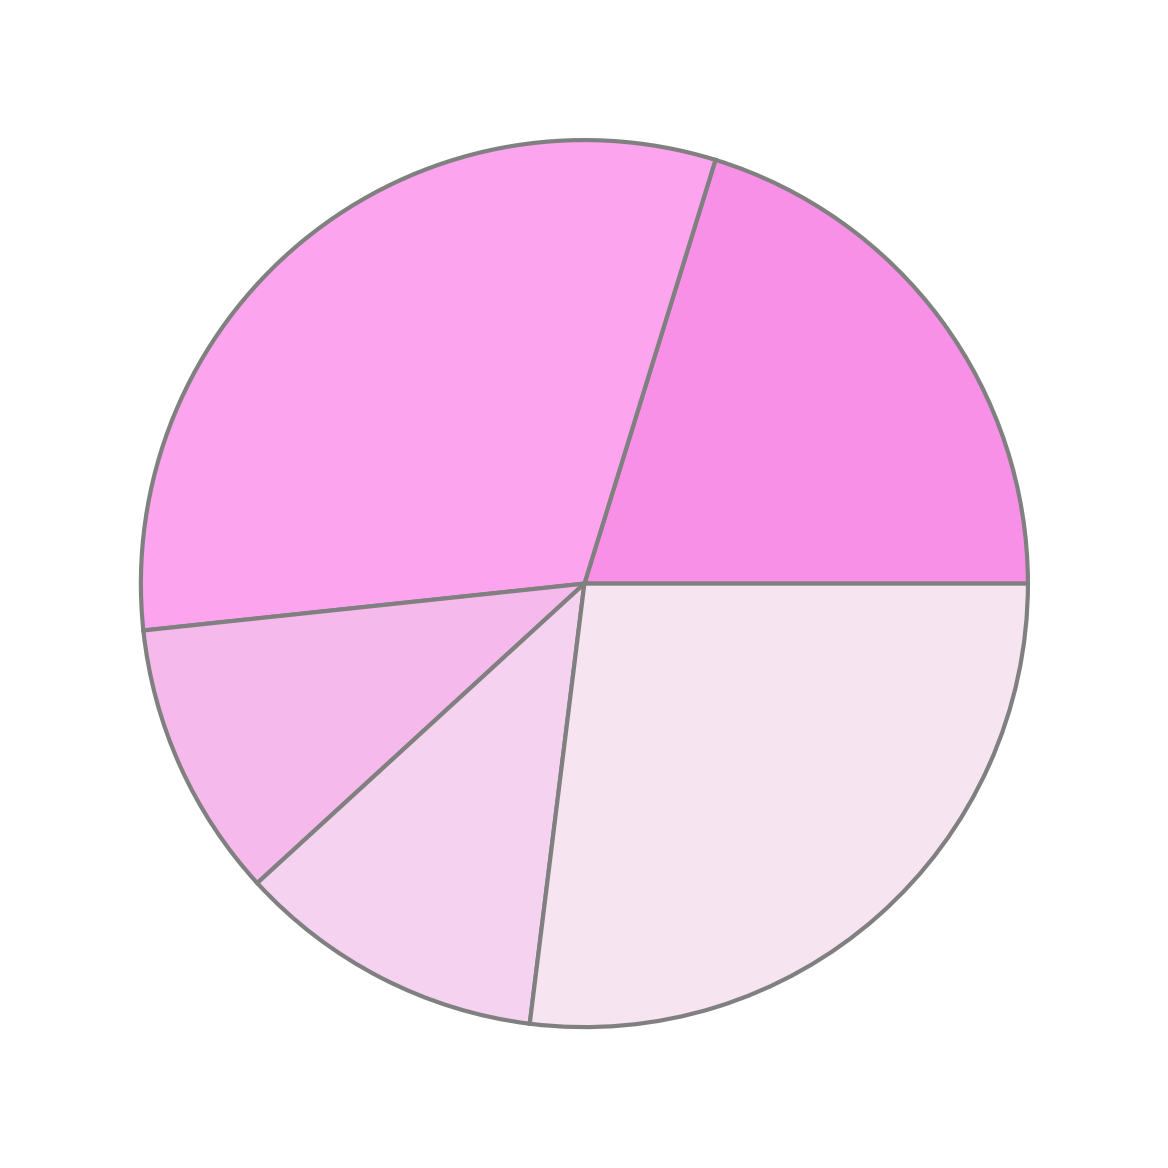

In [ ]:
# Make a pie chart of NHC’s LBs
all_NHC_type = [[],[],[],[], []]
for row in db.select(category="LB"):
    if int(row.key.split("_")[1]) in NHC_LB:
        if Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("C1CN[C]N1")):
            all_NHC_type[0].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("C1=CN[C]N1")):
            all_NHC_type[1].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("c1cN[C]N1")):
            all_NHC_type[1].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[C,c]1~[N,n]N[C]N1")):
            all_NHC_type[2].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[C,c]1[C,c,N,n][C,c]N[C]N1")):
            all_NHC_type[3].append(row.smiles)
        else:
            all_NHC_type[4].append(row.smiles)
colors = ["#f990e7", "#fca4ed", "#f6b9ec", "#f5d2ef", "#f6e4f0"]
NHC_nums = [len(each) for each in all_NHC_type]
print(NHC_nums)
plt.figure(dpi=300)
plt.pie(NHC_nums, colors=colors, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_NHC_TypeColors.png", dpi=300)

# 9237 TS Distribution

TS number in db: 9237
['27.1%', '64.2%', '8.7%']
['2.3%', '19.4%', '22.8%', '55.5%']
['63.8%', '19.8%', '16.3%']


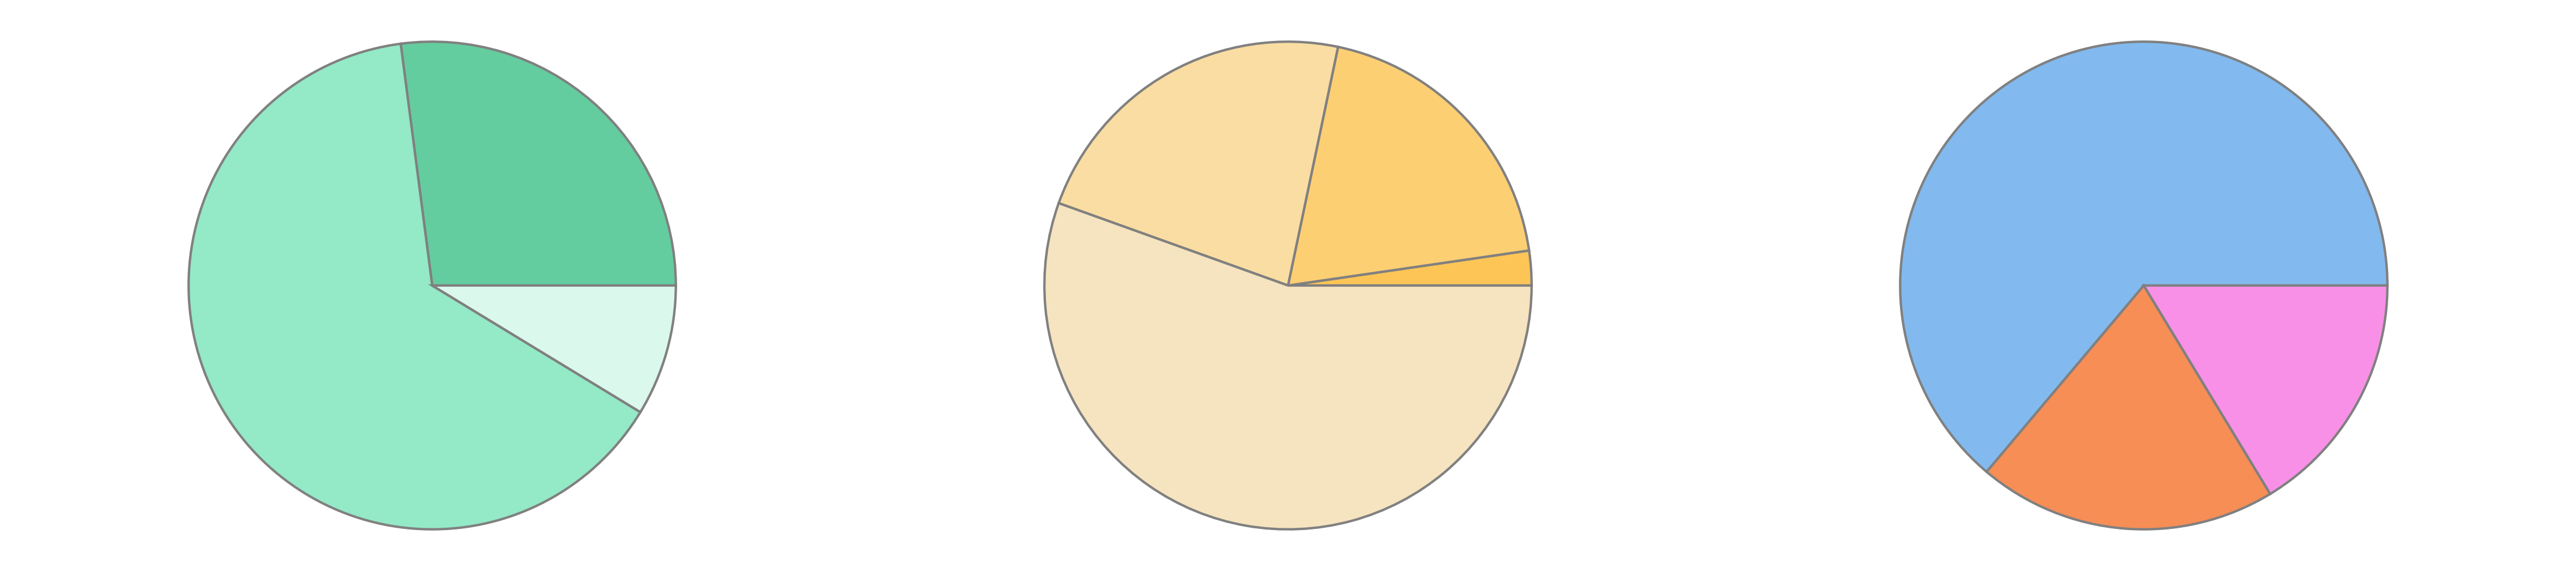

In [59]:
ts_df = pd.DataFrame([
    {
        "key": row.key,
        "B_id": int(row.B_id),
        "LB_id": int(row.LB_id),
        "Cl_id": int(row.Cl_id),
        "barrier_kcal": row.barrier_kcal,
        "delta_g_rxn_kcal": row.delta_g_rxn_kcal,
    }
    for row in db.select(category="ts")
])

print("TS number in db:", len(ts_df))


# ---------- LB type ----------
Anime_LB = np.arange(0, 69)
Phosphine_LB = np.arange(69, 144)
NHC_LB = np.arange(144, 234)
Ar_LB = np.arange(234, 388)

def get_lb_type(lb_id):
    if lb_id in np.append(Anime_LB, Ar_LB):
        return "Amine/Aryl N"
    if lb_id in Phosphine_LB:
        return "Phosphine"
    if lb_id in NHC_LB:
        return "NHC"
    return "Other"


# ---------- B radical type ----------
def get_boron_type(smiles):
    mol = Chem.MolFromSmiles(smiles)
    b_atom = [a for a in mol.GetAtoms() if a.GetSymbol() == "B"][0]
    n_h = b_atom.GetTotalNumHs()
    return {0: "BR3", 1: "R2BH", 2: "RBH2", 3: "BH3"}.get(n_h, f"BH{n_h}")

B_type_map = {
    int(row.B_id): get_boron_type(row.smiles)
    for row in db.select(category="B")
}


# ---------- chloride substrate type ----------
def get_cl_substrate_type(smiles):
    Cl_mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*(Cl)(Cl)Cl")):
        return "CCl4"
    elif Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*(Cl)Cl")):
        return "CCl3"
    elif Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*Cl")):
        return "CCl2"
    else:
        return "CCl"

Cl_type_map = {
    int(row.Cl_id): get_cl_substrate_type(row.smiles)
    for row in db.select(category="Cl")
}


ts_df["LB_type"] = ts_df["LB_id"].map(get_lb_type)
ts_df["B_type"] = ts_df["B_id"].map(B_type_map)
ts_df["Cl_type"] = ts_df["Cl_id"].map(Cl_type_map)


def plot_type_pie(ax, s, title, colors, order=None):
    counts = s.value_counts()
    if order is not None:
        counts = counts.reindex(order).dropna().astype(int)
    ax.pie(
        counts.values,
        colors=colors[:len(counts)],
        startangle=0,
        wedgeprops={"edgecolor": "gray", "linewidth": 1},
    )
    # ax.set_title(title, fontsize=12)
    ax.axis("equal")
    return counts

def pct_list(counts):
    return [f"{pct:.1f}%" for pct in counts / counts.sum() * 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), dpi=300)

b_counts = plot_type_pie(
    axes[0],
    ts_df["B_type"],
    "Boron radical type",
    [ "#64cd9f", "#94e9c6", "#dbf8ec"],
    order=["BR3", "R2BH", "RBH2", "BH3"],
)
cl_counts = plot_type_pie(
    axes[1],
    ts_df["Cl_type"],
    "Chloride substrate type",
    ["#fcc556", "#fdcf73", "#fadda2", "#f6e4c0"],
    order=["CCl4", "CCl3", "CCl2", "CCl"],
)
lb_counts = plot_type_pie(
    axes[2],
    ts_df["LB_type"],
    "Lewis base type",
    ["#82baef", "#f68e56", "#f990e7"],
    order=["Amine/Aryl N", "Phosphine", "NHC"],
)

print(pct_list(b_counts))
print(pct_list(cl_counts))
print(pct_list(lb_counts))

plt.tight_layout()
plt.savefig("Figure/TS_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


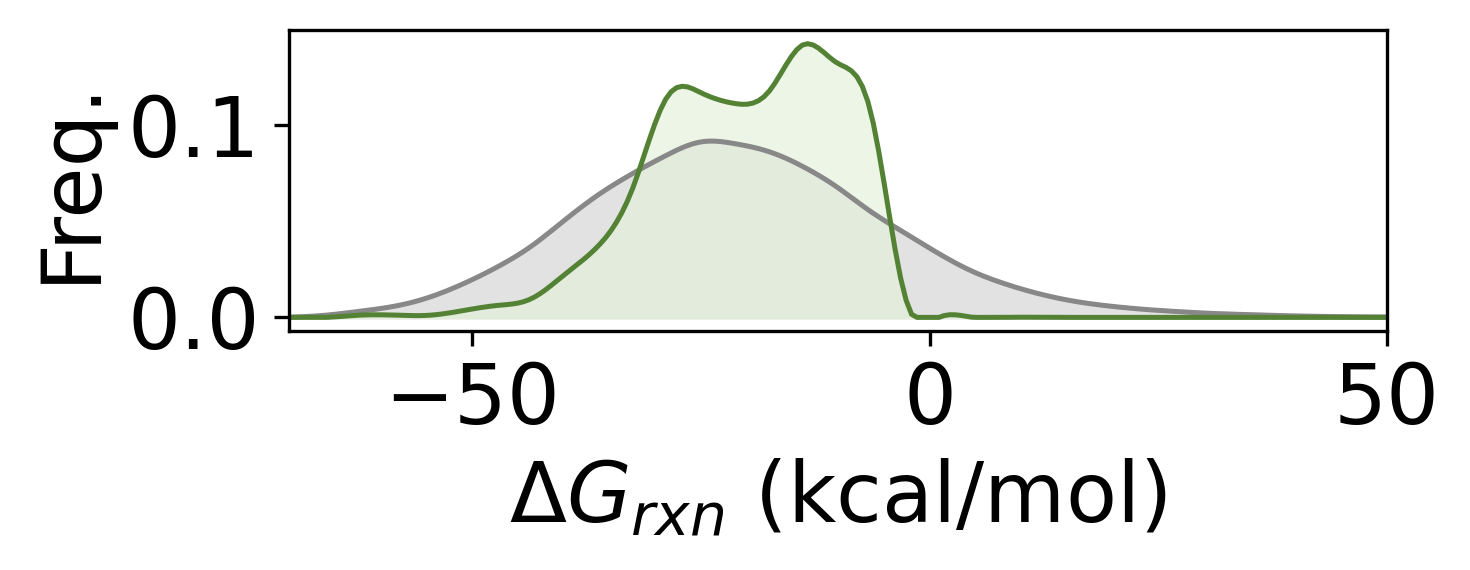

In [52]:
HARTREE_TO_KCAL = 627.509

# TS reaction thermodynamics from database
ts_deltaG = ts_df["delta_g_rxn_kcal"].dropna().to_numpy()

# all possible LB-B + C-Cl reaction thermodynamics
bn_df = pd.read_csv("Data/csvs/reactants_B_N.csv")
cl_df = pd.read_csv("Data/csvs/reactants_Cl.csv")

bn_dg = bn_df["deltaG_react"].dropna().to_numpy()
cl_dg = cl_df["deltaG_react"].dropna().to_numpy()

all_rxn_deltaG = (bn_dg[:, None] + cl_dg[None, :]).ravel() * HARTREE_TO_KCAL

fig, ax = plt.subplots(figsize=(5, 2), dpi=300)

# TS reaction free energy vs all possible reactions
common_bins = np.linspace(
    min(ts_deltaG.min(), all_rxn_deltaG.min()),
    max(ts_deltaG.max(), all_rxn_deltaG.max()),
    50,
)

plot_distribution(
    ax,
    all_rxn_deltaG,
    orientation="top",
    bins=common_bins,
    color_line="#888888",
    color_fill=(0.75, 0.75, 0.75, 0.45),
    write_axis=True,
)
plot_distribution(
    ax,
    ts_deltaG,
    orientation="top",
    bins=common_bins,
    color_line="#548235",
    color_fill=(226/255, 240/255, 217/255, 0.65),
    write_axis=True,
)

ax.set_xlabel(r"$\Delta G_{rxn}$ (kcal/mol)", fontsize=20)
ax.set_ylabel("Freq.", fontsize=20)
# ax.set_title("Reaction thermodynamics", fontsize=20)
ax.tick_params(labelsize=20)

all_rxn_line, ts_line = ax.lines[-2], ax.lines[-1]
# ax.legend(
#     handles=[all_rxn_line, ts_line],
#     labels=["All LB-B + C-Cl", "TS subset"],
#     frameon=False,
#     fontsize=14,
#     loc="upper right"
# )
plt.xlim(-70, 50)
plt.tight_layout()
plt.savefig("Figure/TS_thermo_vs_all_reactions.png", dpi=300, bbox_inches="tight")
plt.show()


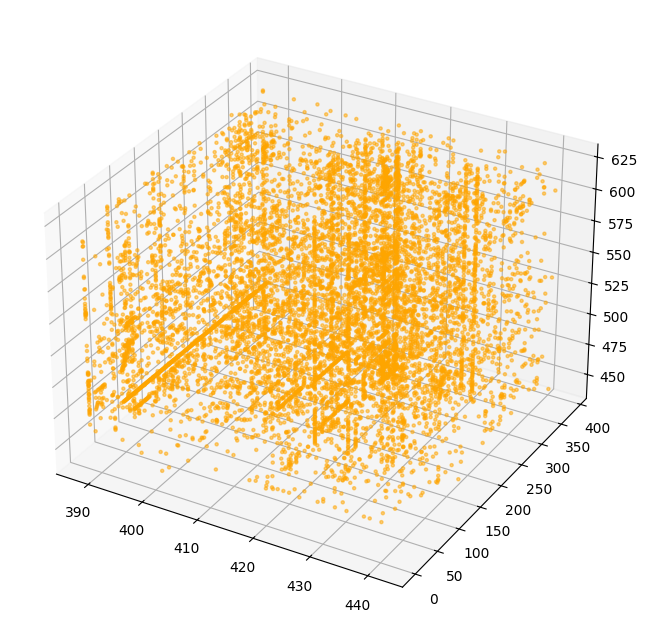

In [63]:
all_success_bs = reaction_df['B_Index'].to_numpy()
all_success_ns = reaction_df['N_Index'].to_numpy()
all_success_cls = reaction_df['Cl_Index'].to_numpy()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_success_bs, all_success_ns, all_success_cls, c='orange', marker='o', s=5, alpha=0.5)
plt.savefig("Figure/Figure1_3D.png", dpi=300)

## Selection 1 The most common Borane, Nu

In [6]:
B_N_Full_df = pd.read_csv("Data/csvs/reactants_B_N_full.csv").dropna(subset=['deltaG_comb(kcal)'])
selected_BN = B_N_Full_df.loc[B_N_Full_df['deltaG_comb(kcal)'] < -4.1]
dropped_BN = B_N_Full_df.loc[B_N_Full_df['deltaG_comb(kcal)'] > -4.1]


In [32]:
B_average_Gcomb = {}
for _, row in B_N_Full_df.iterrows():
    if row.B_smiles in B_average_Gcomb.keys():
        B_average_Gcomb[row.B_smiles].append(row['deltaG_comb(kcal)'])
    else:
        B_average_Gcomb[row.B_smiles] = [row['deltaG_comb(kcal)']]
B_average_Gcomb = {key: sum(value) / len(value) for key, value in B_average_Gcomb.items()}
B_average_Gcomb = sorted(B_average_Gcomb.items(), key=lambda x: x[1])
N_average_Gcomb = {}
for _, row in B_N_Full_df.iterrows():
    if row.N_smiles in N_average_Gcomb.keys():
        N_average_Gcomb[row.N_smiles].append(row['deltaG_comb(kcal)'])
    else:
        N_average_Gcomb[row.N_smiles] = [row['deltaG_comb(kcal)']]
N_average_Gcomb = {key: sum(value) / len(value) for key, value in N_average_Gcomb.items()}
N_average_Gcomb = sorted(N_average_Gcomb.items(), key=lambda x: x[1])

In [33]:
B_select_num = {}
for _, row in selected_BN.iterrows():
    if row.B_smiles in B_select_num.keys():
        B_select_num[row.B_smiles] += 1
    else:
        B_select_num[row.B_smiles] = 1
B_dropped_num = {}
for _, row in dropped_BN.iterrows():
    if row.B_smiles in B_dropped_num.keys():
        B_dropped_num[row.B_smiles] += 1
    else:
        B_dropped_num[row.B_smiles] = 1
B_select_num = sorted(B_select_num.items(), key=lambda x: x[1], reverse=True)
B_dropped_num = sorted(B_dropped_num.items(), key=lambda x: x[1], reverse=True)

In [34]:
N_select_num = {}
for _, row in selected_BN.iterrows():
    if row.N_smiles in N_select_num.keys():
        N_select_num[row.N_smiles] += 1
    else:
        N_select_num[row.N_smiles] = 1
N_dropped_num = {}
for _, row in dropped_BN.iterrows():
    if row.N_smiles in N_dropped_num.keys():
        N_dropped_num[row.N_smiles] += 1
    else:
        N_dropped_num[row.N_smiles] = 1
N_select_num = sorted(N_select_num.items(), key=lambda x: x[1], reverse=True)
N_dropped_num = sorted(N_dropped_num.items(), key=lambda x: x[1], reverse=True)

In [35]:
N_dropped_num[:5], B_dropped_num[:5]

([('c1ccc(N(c2ccccc2)c2ccccc2)cc1', 30),
  ('N#CN1CCOCC1', 29),
  ('CN(C)C(F)(F)F', 27),
  ('Cc1c[nH]c(N)n1', 27),
  ('N#CN1CCCCC1', 26)],
 [('CN1BN(C)CC1', 97),
  ('B1OCCO1', 77),
  ('BN(C)C', 65),
  ('CBOC', 62),
  ('B1CCCO1', 48)])

In [39]:
csv_1 = pd.read_csv(r'Data\csvs\reactants_B_N.csv')
csv_2 = pd.read_csv(r"Data\csvs\reactants_Cl.csv")
for Cl_BDE in np.sort(csv_2['BDE_G'].to_numpy())[::-1][:5]:
    print(len(csv_1.loc[csv_1['BDE_G'] < Cl_BDE]))
for B_BDE in np.sort(csv_1['BDE_G'].to_numpy())[:5]:
    print(len(csv_2.loc[csv_2['BDE_G'] > B_BDE]))

19730
18981
12218
11936
10354
179
179
179
179
179


# Figure 4

## Relation deltaG and deltaGa

coef: [ 0.45954884 30.2574423 ]
Pearson r: 0.725
R^2: 0.525


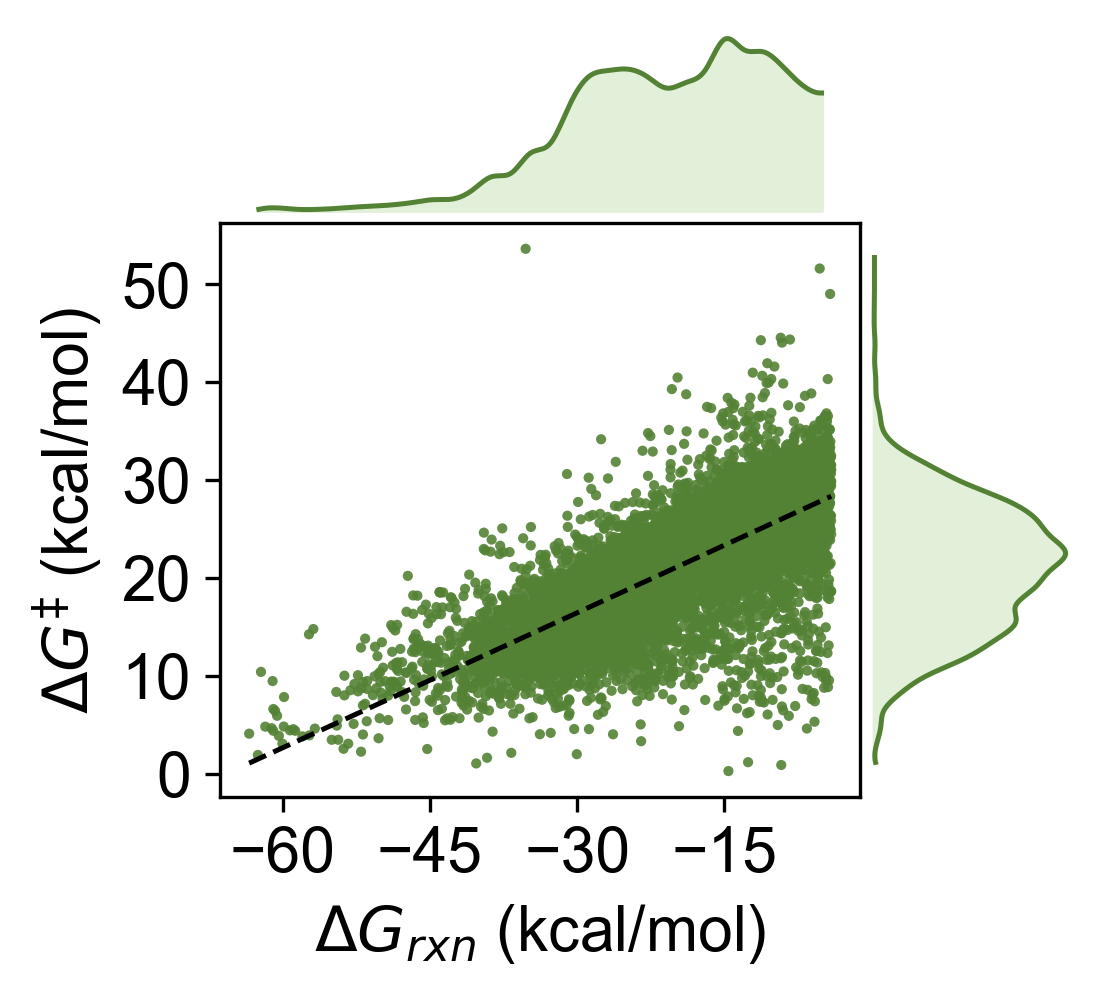

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ===== Data =====
x = reaction_df['deltaG(kcal/mol)'].to_numpy()
y = reaction_df['deltaGa(kcal/mol)'].to_numpy()

# ===== Style =====
plt.rcParams['font.sans-serif'] = 'Arial'

color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)

# ===== Layout =====
fig = plt.figure(figsize=(4.5,3.5), dpi=300)
gs = fig.add_gridspec(5,5)

ax_main = fig.add_subplot(gs[1:4,0:3])
ax_top = fig.add_subplot(gs[0,0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4,3], sharey=ax_main)

# ===== Scatter + fit =====
plot_scatter_fit(ax_main, x, y, color=color_main)

# ===== Labels =====
ax_main.set_xlabel(r'$\Delta G_{rxn}$ (kcal/mol)', fontsize=15)
ax_main.set_ylabel(r'$\Delta G^{\ddagger}$ (kcal/mol)', fontsize=15)

ax_main.set_xticks(np.arange(-60,15,15))
ax_main.set_yticks(np.arange(0,60,10))
ax_main.tick_params(labelsize=15)

# ===== Distribution =====
plot_distribution(ax_top, x, 'top', color_line=color_main, color_fill=color_fill)
plot_distribution(ax_right, y, 'right', color_line=color_main, color_fill=color_fill)

# ===== Layout =====
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

plt.savefig("Figure/Figure4_reaction_landscape.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Statistical perspective
all_angles = []
for row_id, row in tqdm(reaction_df.iterrows()):
    B = row['B_Index']
    N = row['N_Index']
    Cl = row['Cl_Index']
    AAM = row['AAM'].split(">>")[0]
    for dbrow in db.select(B_id = B, LB_id = N, Cl_id = Cl):
        position = dbrow.positions
    mol = Chem.MolFromSmiles(AAM)
    B_atom = [atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'B'][0]
    Cl_atoms = [atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'Cl']
    Cl_atoms = sorted(Cl_atoms, key=lambda x: x.GetAtomMapNum())
    C_atom = [atom for atom in mol.GetAtomWithIdx(Cl_atoms[0].GetIdx()).GetNeighbors() if atom.GetSymbol() == 'C'][0]
    angle = get_bond_angle(position[B_atom.GetAtomMapNum() - 1], position[Cl_atoms[0].GetAtomMapNum() - 1], position[C_atom.GetAtomMapNum() - 1])
    all_angles.append(angle)

9237it [16:19,  9.44it/s]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from scipy.interpolate import make_interp_spline

# ===== Data =====
y = reaction_df['deltaGa(kcal/mol)'].to_numpy()
x1 = reaction_df['B_Cl'].to_numpy()
x2 = reaction_df['C_Cl'].to_numpy()
x3 = np.array(all_angles)

# ===== Style =====
plt.rcParams['font.sans-serif'] = 'Arial'
color_main = (84/255, 130/255, 53/255)
color_fill = (226/255, 240/255, 217/255)

# ===== Smooth histogram =====
def smooth_hist(data, bins=30):
    hist, edges = np.histogram(data, bins=bins)
    hist = hist / len(data)
    centers = 0.5 * (edges[:-1] + edges[1:])
    spline = make_interp_spline(centers, hist, k=3)
    x_smooth = np.linspace(centers.min(), centers.max(), 300)
    y_smooth = spline(x_smooth)
    return x_smooth, y_smooth

fig = plt.figure(figsize=(9,3), dpi=300)
gs = fig.add_gridspec(2,3, height_ratios=[1,4])

axes_top = [fig.add_subplot(gs[0,i]) for i in range(3)]
axes_main = [fig.add_subplot(gs[1,i], sharex=axes_top[i]) for i in range(3)]

plot_panel(axes_main[0], axes_top[0], x1, y,
           'B–Cl Distance (Å)', np.arange(2.0,4,0.5),
           ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)',
           color_main="#215f9a", color_fill="#4e95d9")

plot_panel(axes_main[1], axes_top[1], x2, y,
           'C–Cl Distance (Å)', np.arange(1.8,2.8,0.2),
           color_main="#13501b", color_fill="#e2f0d9")

plot_panel(axes_main[2], axes_top[2], x3, y,
           'B–Cl–C angle (°)', np.arange(100,181,20),
           color_main="#c04f15", color_fill="#f5bd9f")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)

plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure In SI

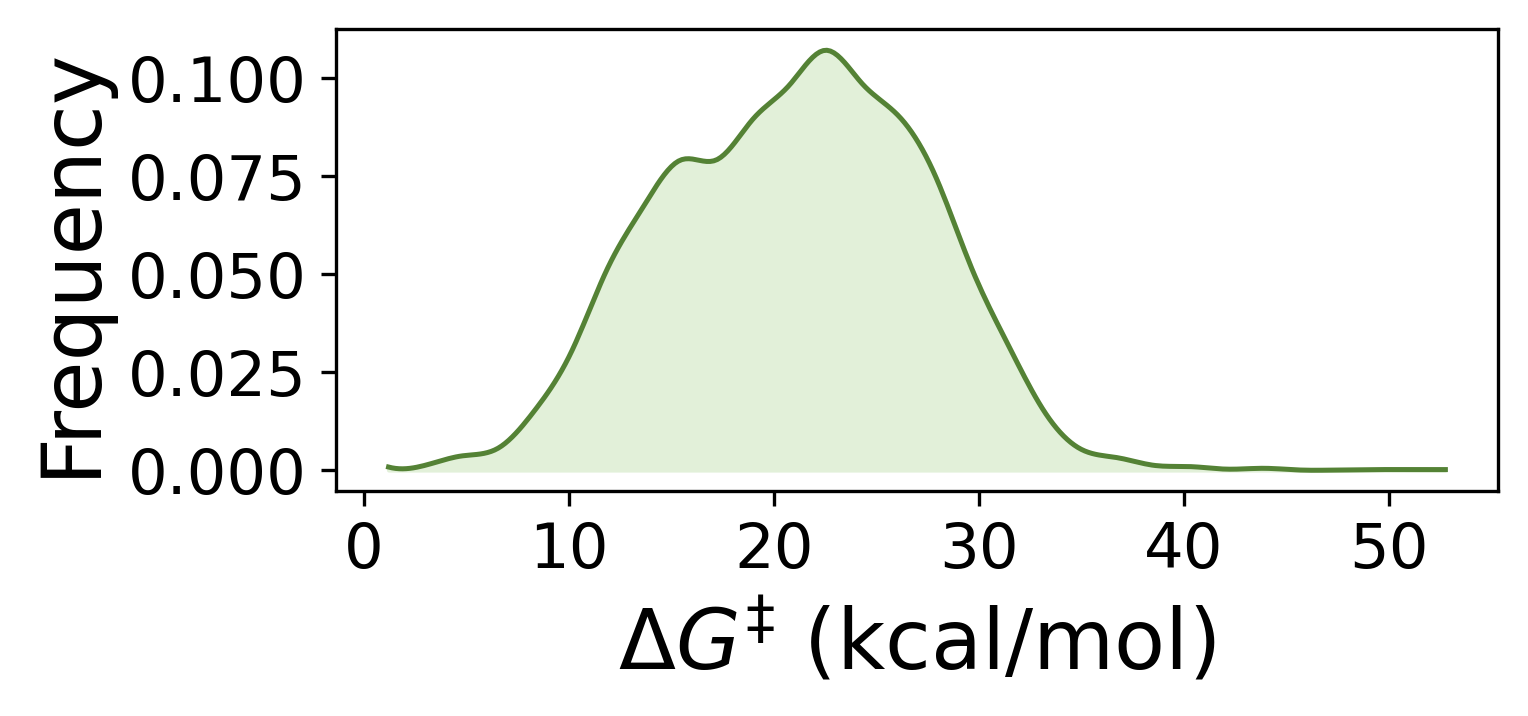

In [28]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\TS\Borane_all.csv")['deltaGa(kcal/mol)']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$\Delta G^{\ddagger}$ (kcal/mol)", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.show()

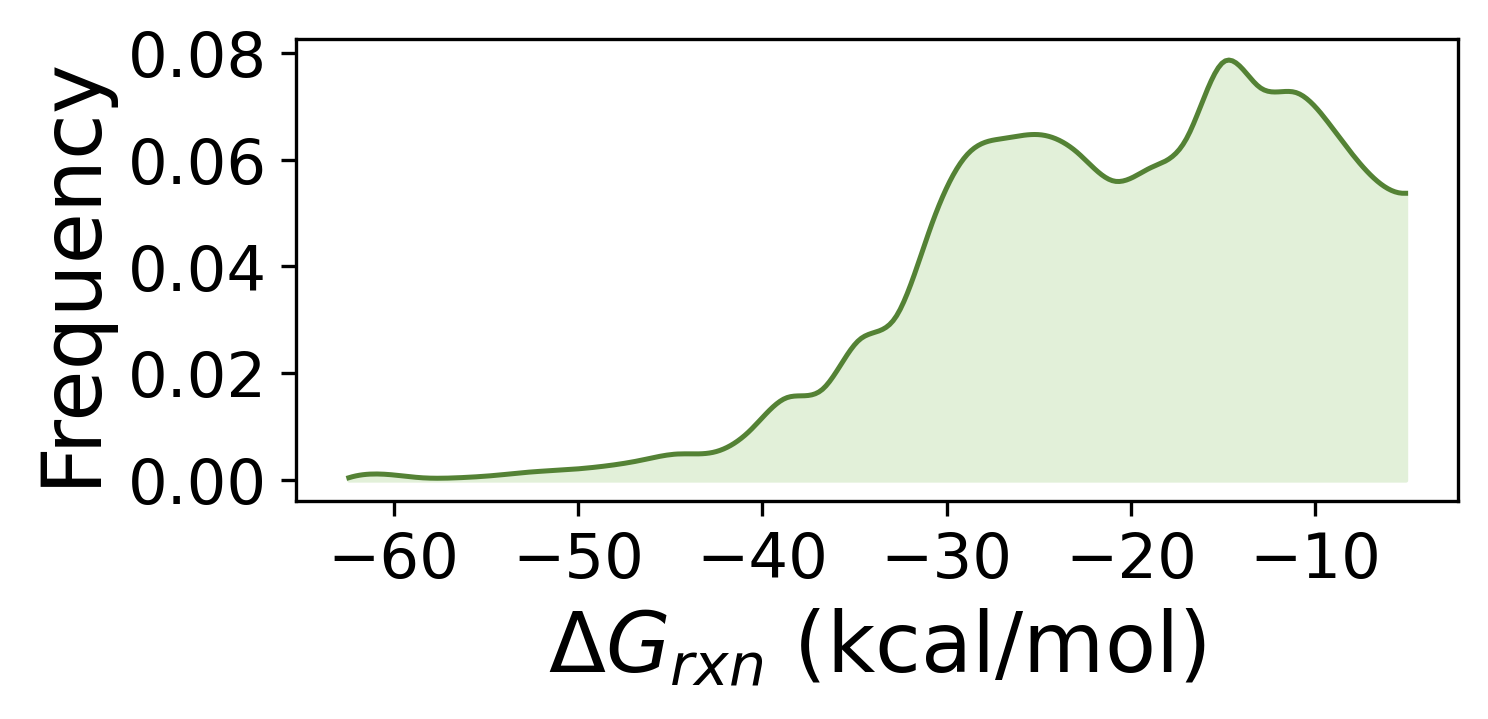

In [29]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\TS\Borane_all.csv")['deltaG(kcal/mol)']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$\Delta G_{rxn}$ (kcal/mol)", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.show()

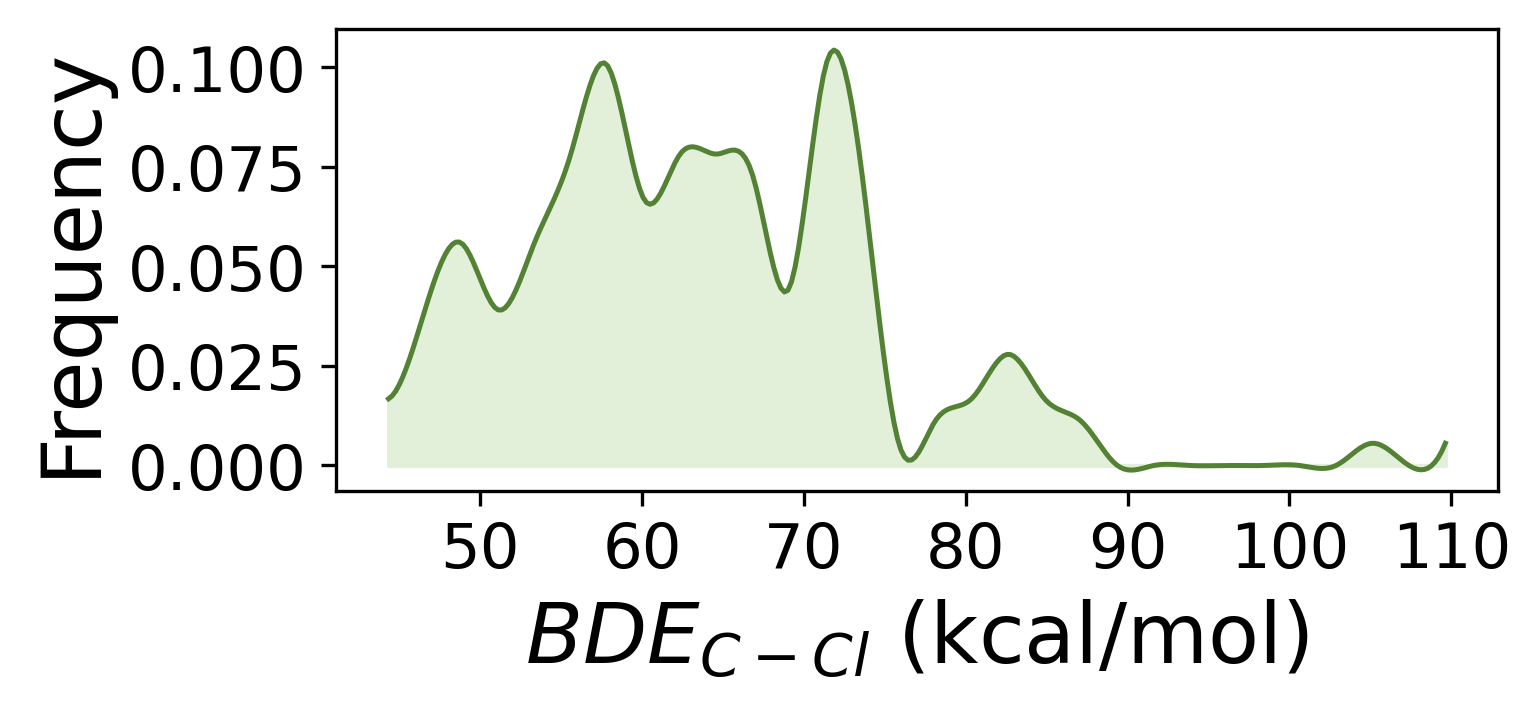

In [ ]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\csvs\reactants_Cl.csv")['BDE_G']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$ BDE_{C-Cl}$ (kcal/mol)", fontsize=20)
# plt.ylabel("Frequency", fontsize=20)
plt.show()

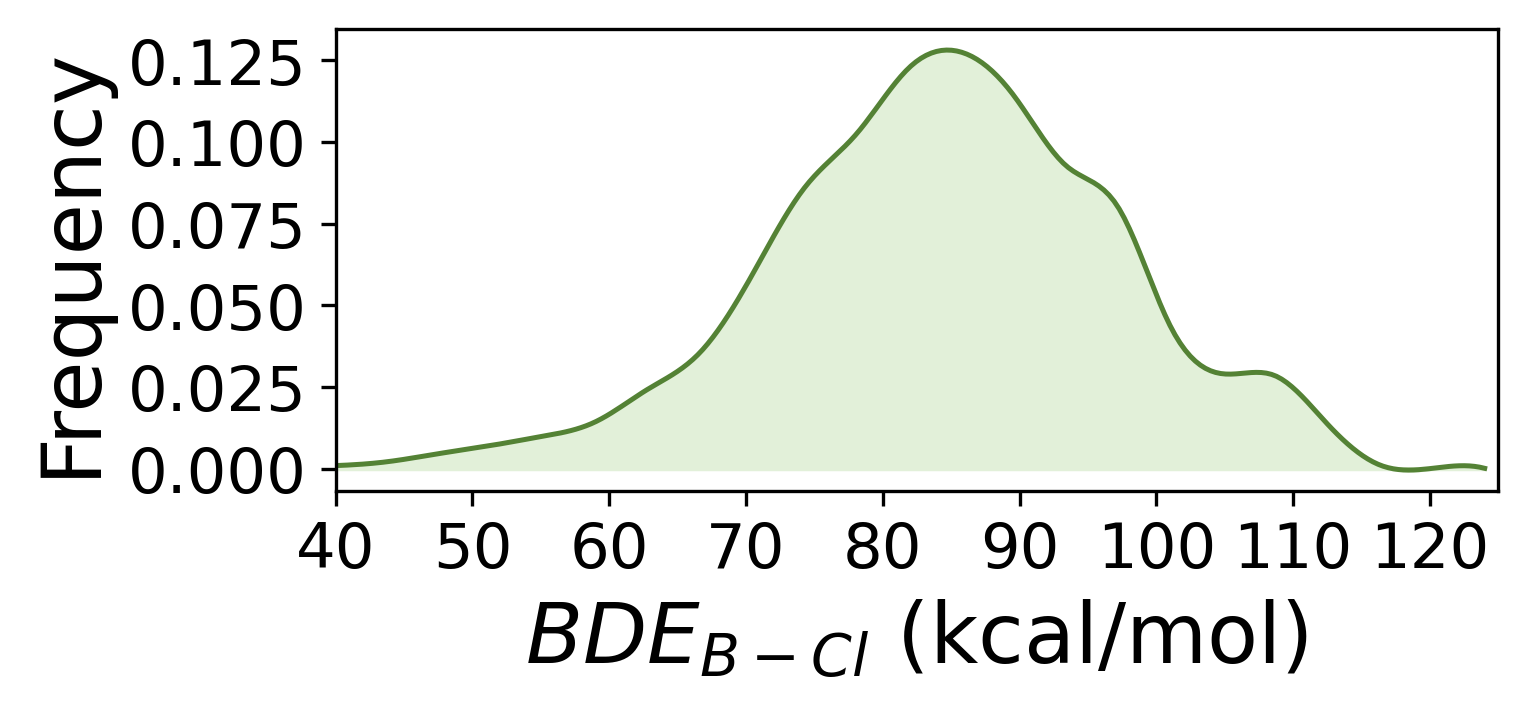

In [10]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\csvs\reactants_B_N.csv")['BDE_G']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(np.arange(0, 0.13, 0.025), fontsize=15)
plt.xlabel("$ BDE_{B-Cl}$ (kcal/mol)", fontsize=20)
plt.xlim(40, 125)
plt.ylabel("Frequency", fontsize=20)
plt.show()